In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [10]:
df_risk_register = pd.read_csv("C:/Users/dell/Downloads/Group_ALY 6130_Risk Factors.csv")

# Preview the first few rows
df_risk_register.head()

,Risk #,The Risk of/That,Likelihood Score,Impact Score
0,1,Market Growth Explosion,9,8
1,2,Venture Capital Advantage,7,6
2,3,High Switching Costs,7,6
3,4,Revenue Model Disadvantage,5,4
4,5,Lost Opportunity Costs,3,4


In [12]:
# Select and rename relevant columns
risk_df = df_risk_register[['Risk #', 'The Risk of/That', 'Likelihood Score', 'Impact Score']].dropna()
risk_df.columns = ['Risk_ID', 'Risk_Description', 'Likelihood_Score', 'Impact_Score']

# Define severity label based on likelihood and impact scores
def classify_severity(row):
    if row['Likelihood_Score'] >= 8 and row['Impact_Score'] >= 5:
        return 'High'
    elif row['Likelihood_Score'] >= 5 or row['Impact_Score'] >= 3:
        return 'Medium'
    else:
        return 'Low'

# Apply function to classify severity
risk_df['Severity_Label'] = risk_df.apply(classify_severity, axis=1)

# View cleaned data
risk_df.head()

,Risk_ID,Risk_Description,Likelihood_Score,Impact_Score,Severity_Label
0,1,Market Growth Explosion,9,8,High
1,2,Venture Capital Advantage,7,6,Medium
2,3,High Switching Costs,7,6,Medium
3,4,Revenue Model Disadvantage,5,4,Medium
4,5,Lost Opportunity Costs,3,4,Medium


### Random Forest Classification

In [14]:
from sklearn.ensemble import RandomForestClassifier

# This model uses a Random Forest classifier with 100 decision trees to predict risk severity levels based on likelihood and impact scores.
# Define the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [16]:
# Re-select features and target : defines the feature matrix (X) using Likelihood and Impact scores, 
# and create the target variable (y) by assigning severity labels (Low, Medium, High) based on a rule-based thresholding logic applied to each risk.
X = df_risk_register[['Likelihood Score', 'Impact Score']]
y = df_risk_register.apply(
    lambda row: 'High' if row['Likelihood Score'] >= 8 and row['Impact Score'] >= 5 
    else 'Medium' if row['Likelihood Score'] >= 5 or row['Impact Score'] >= 3 
    else 'Low',
    axis=1
)

### Cross Validation

In [18]:
from sklearn.model_selection import cross_val_score

# Evaluate the Random Forest model using 5-fold cross-validation, which is preferred over a single train-test split due to the small size of the dataset. 
# Report the mean accuracy across folds and individual fold scores to assess how well the model generalizes to unseen risk classification scenarios.

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Mean accuracy (5-fold CV): {scores.mean():.2f}")
print("Accuracy for each fold:", scores)

Mean accuracy (5-fold CV): 0.98
Accuracy for each fold: [0.91666667 1.         1.         1.         1.        ]


### Building Classification Report

In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=5)

# Classification metrics
print("Classification Report:")
print(classification_report(y, y_pred_cv))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_cv))

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        12
         Low       0.75      1.00      0.86         3
      Medium       1.00      0.98      0.99        45

    accuracy                           0.98        60
   macro avg       0.92      0.99      0.95        60
weighted avg       0.99      0.98      0.98        60

Confusion Matrix:
[[12  0  0]
 [ 0  3  0]
 [ 0  1 44]]


### Interpretation

The model performs exceptionally well despite class imbalance (45 Medium vs. 12 High vs. 3 Low). The majority class (Medium) shows excellent results, and even minority classes achieve strong performance. Only 1 misclassification occurred across all 60 samples.

Recommendation: While current performance is strong, increasing the Low class sample size (currently only 3 samples) would further improve model robustness and generalization, particularly for the precision of Low predictions. A more balanced dataset would provide additional confidence in the model's ability to handle edge cases and ensure sustained performance across all priority levels.

### Building Heatmap

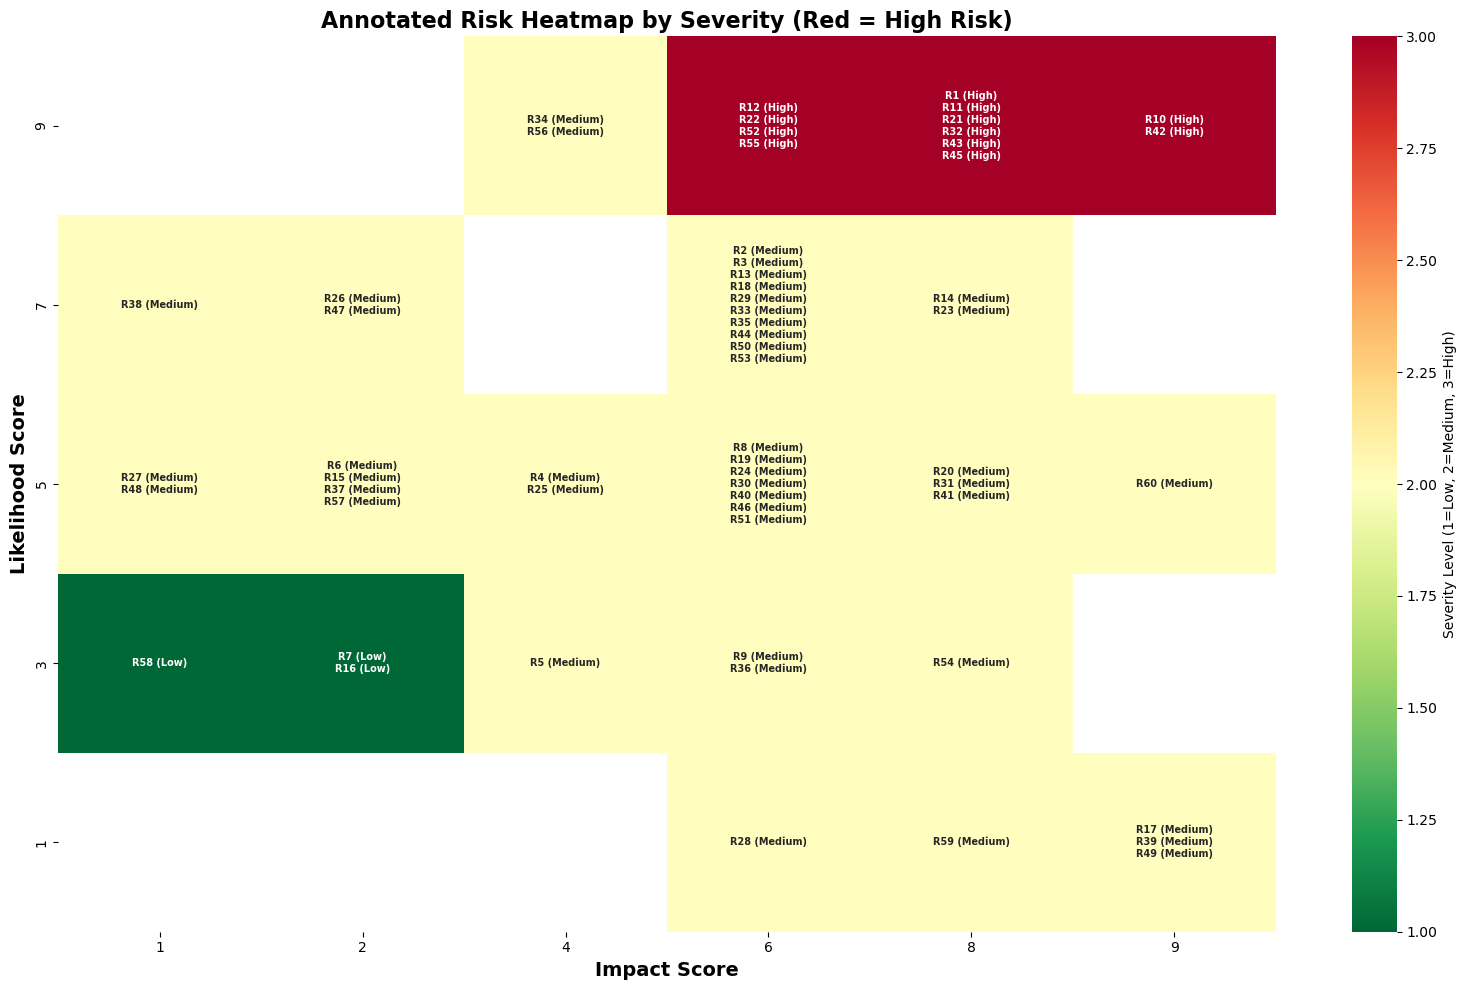

In [48]:
severity_map = df_risk_register.copy()

# Define severity classification logic
def classify_severity(row):
    if row['Likelihood Score'] >= 8 and row['Impact Score'] >= 5:
        return 'High'
    elif row['Likelihood Score'] >= 5 or row['Impact Score'] >= 3:
        return 'Medium'
    else:
        return 'Low'

severity_map['Severity'] = severity_map.apply(classify_severity, axis=1)
severity_levels = {'Low': 1, 'Medium': 2, 'High': 3}
severity_map['Severity_Num'] = severity_map['Severity'].map(severity_levels)
severity_map['Label'] = 'R' + severity_map['Risk #'].astype(str) + ' (' + severity_map['Severity'] + ')'

# Pivot table with most severe risk per cell
pivot_severity = severity_map.groupby(['Likelihood Score', 'Impact Score'])['Severity_Num'].max().unstack(fill_value=0)
pivot_severity = pivot_severity.sort_index(ascending=False)
pivot_severity = pivot_severity[pivot_severity.columns.sort_values()]

# Annotation matrix with ALL risks listed per cell
label_matrix = severity_map.groupby(['Likelihood Score', 'Impact Score'])['Label'] \
                           .apply(lambda x: '\n'.join(x)).unstack(fill_value='')
label_matrix = label_matrix.sort_index(ascending=False)
label_matrix = label_matrix[label_matrix.columns.sort_values()]

# Create mask for empty cells (where value is 0)
mask = pivot_severity == 0

# Plot severity heatmap with annotations
plt.figure(figsize=(16, 10))
ax = sns.heatmap(pivot_severity, annot=label_matrix, fmt='', cmap='RdYlGn_r', 
                 linewidths=0,  # Remove black borders
                 mask=mask,  # Mask empty cells to keep them white
                 cbar_kws={'label': 'Severity Level (1=Low, 2=Medium, 3=High)'},
                 annot_kws={'fontsize': 7, 'fontweight': 'bold'},
                 vmin=1, vmax=3)  # Set range to 1-3 (Low to High)

plt.title("Annotated Risk Heatmap by Severity (Red = High Risk)", 
          fontsize=16, fontweight='bold')
plt.xlabel("Impact Score", fontsize=14, fontweight='bold')
plt.ylabel("Likelihood Score", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Building Confusion Matrix

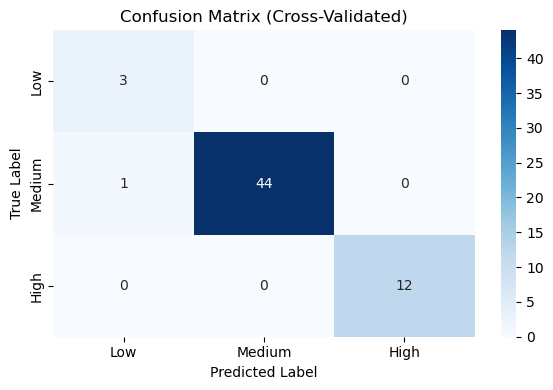

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Reuse model and labels
y_pred_cv = cross_val_predict(model, X, y, cv=5)
conf_matrix = confusion_matrix(y, y_pred_cv, labels=['Low', 'Medium', 'High'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix (Cross-Validated)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Interpretation
The matrix shows how well the model predicts the risk severity levels (Low, Medium, High) based on the likelihood and impact scores. We're using a Random Forest classifier to predict one of three severity categories: Low, Medium, and High.

### Confusion Matrix Breakdown

44 out of 45 Medium risks were correctly predicted: Excellent performance on the majority class with only 1 misclassification.

All 12 High risks were correctly predicted: Perfect performance, the model successfully identified all high-severity risks without any false negatives or false positives.

Only 1 misclassification occurred: One Medium risk was incorrectly predicted as Low. This represents the only error in the entire validation set.